# West Coast vs East Coast Seasonal Temperature Predictability

We compare whether current-season climate indices can help predict next-season temperature anomalies for the U.S. West Coast and East Coast.

Our main model is multiple linear regression. We also compare simpler models so we can see whether adding PDO and AO improves prediction beyond Niño 3.4 alone.

The goal is not just to make a prediction. We want to compare where and when the climate indices have useful signal.

## Project Question

Can current-season Niño 3.4, PDO, and AO help predict next-season seasonal-mean temperature anomalies for coastal regions of the western and eastern United States?

We focus on three comparisons:

- West Coast vs East Coast predictability.
- Full model vs simpler climate-index models.
- Seasonal differences in out-of-sample model skill.

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Helper Functions

We keep the helper functions small. One helper reads climate index files with one year and 12 monthly values. Another helper converts monthly data into complete seasonal means.

In [2]:
SECTION_LINE = "=" * 70
MISSING_VALUES = [99.99, -99.99, 999, -999, -9999]
SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]
SEASON_TO_NUMBER = {"DJF": 0, "MAM": 1, "JJA": 2, "SON": 3}


def load_year_month_index(file_path, column_name):
    rows = []

    with open(file_path, "r") as data_file:
        for line in data_file:
            parts = line.split()

            # Keep rows with one year and 12 monthly values.
            if len(parts) == 13 and parts[0].isdigit():
                year = int(parts[0])

                for month, value in enumerate(parts[1:], start=1):
                    rows.append({
                        "date": pd.Timestamp(year=year, month=month, day=1),
                        column_name: float(value),
                    })

    data = pd.DataFrame(rows).set_index("date").sort_index()
    data = data.replace(MISSING_VALUES, np.nan)

    return data


def make_seasonal_mean(monthly_data):
    data = monthly_data.copy()
    data["month"] = data.index.month
    data["season_year"] = data.index.year

    # December belongs to the next DJF season year.
    data.loc[data["month"] == 12, "season_year"] += 1

    season_by_month = {
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON",
    }
    data["season"] = data["month"].map(season_by_month)

    value_columns = [col for col in data.columns if col not in ["month", "season_year", "season"]]
    grouped = data.groupby(["season_year", "season"])

    seasonal_mean = grouped[value_columns].mean()
    seasonal_count = grouped[value_columns].count()

    # Keep only seasons with all 3 months for every value column.
    complete_seasons = seasonal_count.eq(3).all(axis=1)
    seasonal_mean = seasonal_mean.loc[complete_seasons].reset_index()

    seasonal_mean["season"] = pd.Categorical(
        seasonal_mean["season"],
        categories=SEASON_ORDER,
        ordered=True,
    )
    seasonal_mean = seasonal_mean.sort_values(["season_year", "season"]).reset_index(drop=True)
    seasonal_mean["season"] = seasonal_mean["season"].astype(str)
    seasonal_mean["season_number"] = seasonal_mean["season"].map(SEASON_TO_NUMBER)
    seasonal_mean["season_id"] = seasonal_mean["season_year"] * 4 + seasonal_mean["season_number"]
    seasonal_mean["season_label"] = seasonal_mean["season_year"].astype(str) + " " + seasonal_mean["season"]

    return seasonal_mean

## Load and Clean the Data

We use four data sources: ERA5 monthly 2m temperature, Niño 3.4, PDO, and AO. We only do basic checks here so the notebook stays focused on the final prediction task.

In [3]:
print(SECTION_LINE)
print("LOAD ERA5 TEMPERATURE")
print(SECTION_LINE)

era5_data = xr.open_dataset("data/ERA5_2mtemp_1x1.nc")
temperature_variable = list(era5_data.data_vars)[0]
era5_temperature_kelvin = era5_data[temperature_variable]
era5_temperature_celsius = era5_temperature_kelvin - 273.15

print("Temperature variable:", temperature_variable)
print("Variable description:", era5_temperature_kelvin.attrs.get("variable", "not listed"))
print("Units before conversion:", era5_temperature_kelvin.attrs.get("units", "not listed"))
print("Time range:", str(era5_temperature_kelvin.time.min().values)[:10], "to", str(era5_temperature_kelvin.time.max().values)[:10])
print("Grid size:", dict(era5_temperature_kelvin.sizes))

print()
print("Quick Celsius summary:")
print(pd.Series({
    "mean": float(era5_temperature_celsius.astype("float64").mean().values),
    "min": float(era5_temperature_celsius.astype("float64").min().values),
    "max": float(era5_temperature_celsius.astype("float64").max().values),
}))

LOAD ERA5 TEMPERATURE
Temperature variable: __xarray_dataarray_variable__
Variable description: 2m air temperature
Units before conversion: K
Time range: 1959-01-01 to 2024-12-01
Grid size: {'time': 792, 'lat': 180, 'lon': 360}

Quick Celsius summary:
mean     5.196828
min    -73.219269
max     43.082428
dtype: float64


In [4]:
print(SECTION_LINE)
print("LOAD CLIMATE INDICES")
print(SECTION_LINE)

nino34_data = load_year_month_index("data/nina34.anom.data", "nino34")
pdo_data = load_year_month_index("data/ersst.v5.pdo.dat", "pdo")

ao_data = pd.read_csv(
    "data/ao.long.csv",
    names=["date", "ao"],
    header=0,
    skipinitialspace=True,
)
ao_data["date"] = pd.to_datetime(ao_data["date"])
ao_data["ao"] = pd.to_numeric(ao_data["ao"], errors="coerce")
ao_data = ao_data.set_index("date").sort_index()
ao_data = ao_data.replace(MISSING_VALUES, np.nan)

climate_indices_monthly = pd.concat([nino34_data, pdo_data, ao_data], axis=1).sort_index()
climate_indices_monthly = climate_indices_monthly.dropna(how="all")

print("Monthly climate index date range:", climate_indices_monthly.index.min(), "to", climate_indices_monthly.index.max())
print()
print("Missing values:")
print(climate_indices_monthly.isna().sum())
print()
print("Summary:")
print(climate_indices_monthly.describe())

LOAD CLIMATE INDICES
Monthly climate index date range: 1854-01-01 00:00:00 to 2026-03-01 00:00:00

Missing values:
nino34    1153
pdo          0
ao        1157
dtype: int64

Summary:
           nino34          pdo          ao
count  914.000000  2067.000000  910.000000
mean    -0.177582    -0.349748   -0.083333
std      0.871255     1.160627    0.998798
min     -2.450000    -4.210000   -4.266000
25%     -0.787500    -1.135000   -0.610750
50%     -0.260000    -0.350000   -0.036000
75%      0.350000     0.400000    0.496250
max      2.720000     3.840000    3.495000


/var/folders/66/5m8gb1h54c5c05c3997wt1wm0000gn/T/ipykernel_90464/126700912.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  climate_indices_monthly = pd.concat([nino34_data, pdo_data, ao_data], axis=1).sort_index()


## Define the Two Coastal Regions

We use simple rectangular coastal proxy regions. This keeps the project reproducible and avoids adding shapefiles or extra data.

These boxes are not land-only masks. They are simple regional averages meant to compare broad West Coast and East Coast temperature signals.

In [5]:
regions = {
    "West Coast": {
        "lat_min": 32,
        "lat_max": 49,
        "lon_min": 235,
        "lon_max": 244,
    },
    "East Coast": {
        "lat_min": 25,
        "lat_max": 47,
        "lon_min": 279,
        "lon_max": 295,
    },
}

region_summary = pd.DataFrame(regions).T
print(region_summary)

            lat_min  lat_max  lon_min  lon_max
West Coast       32       49      235      244
East Coast       25       47      279      295


## Compute Regional Monthly Temperature

For each coast, we select the ERA5 grid cells inside the region box and compute an area-weighted monthly mean. We use cosine latitude weights because grid cells represent different surface areas at different latitudes.

In [6]:
regional_temperature_monthly = pd.DataFrame(index=pd.to_datetime(era5_temperature_celsius.time.values))

for region_name, region_box in regions.items():
    region_temperature = era5_temperature_celsius.sel(
        lat=slice(region_box["lat_min"], region_box["lat_max"]),
        lon=slice(region_box["lon_min"], region_box["lon_max"]),
    )

    latitude_weights = np.cos(np.deg2rad(region_temperature.lat))
    weighted_mean = region_temperature.weighted(latitude_weights).mean(dim=["lat", "lon"])

    column_name = region_name.lower().replace(" ", "_") + "_temperature_c"
    regional_temperature_monthly[column_name] = weighted_mean.to_series().values

print("Monthly regional temperature range:", regional_temperature_monthly.index.min(), "to", regional_temperature_monthly.index.max())
print()
print(regional_temperature_monthly.head())
print()
print(regional_temperature_monthly.describe())

Monthly regional temperature range: 1959-01-01 00:00:00 to 2024-12-01 00:00:00

            west_coast_temperature_c  east_coast_temperature_c
1959-01-01                  5.398818                  8.835398
1959-02-01                  4.512365                  9.465461
1959-03-01                  7.783716                 11.247540
1959-04-01                 11.028129                 15.181699
1959-05-01                 11.663748                 18.830984

       west_coast_temperature_c  east_coast_temperature_c
count                792.000000                792.000000
mean                  11.556793                 16.866027
std                    5.709463                  5.395808
min                    0.948843                  5.936727
25%                    6.376622                 11.755902
50%                   11.171087                 16.747025
75%                   16.951282                 22.090483
max                   22.093431                 25.430045


## Seasonal Temperature Anomalies

We convert monthly regional temperature into seasonal means for DJF, MAM, JJA, and SON. Then we compute anomalies by subtracting each region's average for the same season.

This removes the normal seasonal cycle, so the target becomes warmer-than-usual or cooler-than-usual seasonal temperature.

In [7]:
seasonal_temperature = make_seasonal_mean(regional_temperature_monthly)

temperature_columns = [
    "west_coast_temperature_c",
    "east_coast_temperature_c",
]

for column in temperature_columns:
    anomaly_column = column.replace("temperature_c", "anomaly_c")
    seasonal_temperature[anomaly_column] = (
        seasonal_temperature[column]
        - seasonal_temperature.groupby("season")[column].transform("mean")
    )

print("Seasonal temperature date range:", seasonal_temperature["season_label"].iloc[0], "to", seasonal_temperature["season_label"].iloc[-1])
print("Number of complete seasons:", len(seasonal_temperature))
print()
print(seasonal_temperature[[
    "season_year",
    "season",
    "west_coast_anomaly_c",
    "east_coast_anomaly_c",
]].head())
print()
print(seasonal_temperature[["west_coast_anomaly_c", "east_coast_anomaly_c"]].describe())

Seasonal temperature date range: 1959 MAM to 2024 SON
Number of complete seasons: 263

   season_year season  west_coast_anomaly_c  east_coast_anomaly_c
0         1959    MAM              0.008044              0.025009
1         1959    JJA             -0.117059             -0.104381
2         1959    SON             -0.315661              0.270713
3         1960    DJF             -0.847931              0.204824
4         1960    MAM             -0.362092             -0.980215

       west_coast_anomaly_c  east_coast_anomaly_c
count          2.630000e+02          2.630000e+02
mean           2.431515e-16          3.782357e-16
std            8.769275e-01          6.922616e-01
min           -2.513859e+00         -2.049729e+00
25%           -5.633555e-01         -4.512745e-01
50%            1.286872e-02          4.881655e-03
75%            6.639635e-01          4.264194e-01
max            2.804469e+00          2.129600e+00


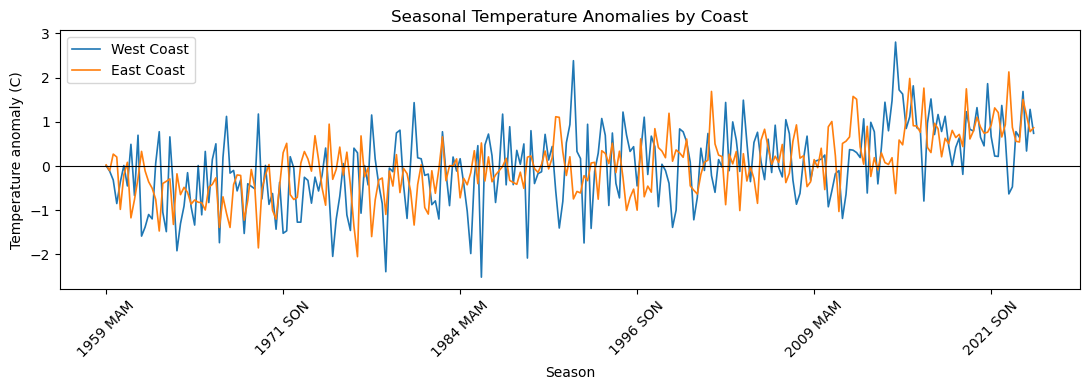

In [8]:
plot_data = seasonal_temperature.set_index("season_label")[[
    "west_coast_anomaly_c",
    "east_coast_anomaly_c",
]]

ax = plot_data.plot(figsize=(11, 4), linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Seasonal Temperature Anomalies by Coast")
ax.set_xlabel("Season")
ax.set_ylabel("Temperature anomaly (C)")
ax.legend(["West Coast", "East Coast"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Seasonal Climate Indices

We convert Niño 3.4, PDO, and AO into seasonal means using the same seasonal helper. These current-season values will become predictors for next-season temperature anomalies.

In [9]:
seasonal_climate_indices = make_seasonal_mean(climate_indices_monthly)

print("Seasonal climate index range:", seasonal_climate_indices["season_label"].iloc[0], "to", seasonal_climate_indices["season_label"].iloc[-1])
print("Number of complete seasons:", len(seasonal_climate_indices))
print()
print(seasonal_climate_indices[["season_year", "season", "nino34", "pdo", "ao"]].head())
print()
print(seasonal_climate_indices[["nino34", "pdo", "ao"]].describe())

Seasonal climate index range: 1950 MAM to 2025 JJA
Number of complete seasons: 302

   season_year season    nino34       pdo        ao
0         1950    MAM -1.570000 -2.356667  0.206333
1         1950    JJA -1.083333 -3.050000 -0.371333
2         1950    SON -1.080000 -1.923333 -0.178667
3         1951    DJF -1.216667 -1.256667 -0.804333
4         1951    MAM -0.206667 -1.453333 -1.191000

           nino34         pdo          ao
count  302.000000  302.000000  302.000000
mean    -0.171490   -0.481302   -0.084450
std      0.849770    1.089608    0.702916
min     -2.063333   -3.496667   -3.422000
25%     -0.780000   -1.276667   -0.453250
50%     -0.250000   -0.475000   -0.074333
75%      0.335833    0.280833    0.319917
max      2.496667    2.103333    2.688000


## Build the One-Season-Ahead Prediction Dataset

Each row uses current-season climate indices to predict next-season temperature anomaly. For example, current-season Niño 3.4, PDO, and AO in one season are paired with West Coast and East Coast temperature anomalies in the following season.

In [10]:
predictors = seasonal_climate_indices[[
    "season_year",
    "season",
    "season_id",
    "season_label",
    "nino34",
    "pdo",
    "ao",
]].copy()

predictors = predictors.rename(columns={
    "season_year": "predictor_season_year",
    "season": "predictor_season",
    "season_id": "predictor_season_id",
    "season_label": "predictor_season_label",
})

targets = seasonal_temperature[[
    "season_year",
    "season",
    "season_id",
    "season_label",
    "west_coast_anomaly_c",
    "east_coast_anomaly_c",
]].copy()

targets["predictor_season_id"] = targets["season_id"] - 1
targets = targets.rename(columns={
    "season_year": "target_season_year",
    "season": "target_season",
    "season_id": "target_season_id",
    "season_label": "target_season_label",
    "west_coast_anomaly_c": "next_west_coast_anomaly_c",
    "east_coast_anomaly_c": "next_east_coast_anomaly_c",
})

modeling_data = predictors.merge(targets, on="predictor_season_id", how="inner")
modeling_data = modeling_data.dropna(subset=[
    "nino34",
    "pdo",
    "ao",
    "next_west_coast_anomaly_c",
    "next_east_coast_anomaly_c",
]).sort_values("target_season_id").reset_index(drop=True)

print("Modeling rows:", len(modeling_data))
print("Predictor season range:", modeling_data["predictor_season_label"].iloc[0], "to", modeling_data["predictor_season_label"].iloc[-1])
print("Target season range:", modeling_data["target_season_label"].iloc[0], "to", modeling_data["target_season_label"].iloc[-1])
print()
print(modeling_data[[
    "predictor_season_label",
    "target_season_label",
    "nino34",
    "pdo",
    "ao",
    "next_west_coast_anomaly_c",
    "next_east_coast_anomaly_c",
]].head())

Modeling rows: 263
Predictor season range: 1959 DJF to 2024 JJA
Target season range: 1959 MAM to 2024 SON

  predictor_season_label target_season_label    nino34       pdo        ao  \
0               1959 DJF            1959 MAM  0.326667  0.843333 -0.385333   
1               1959 MAM            1959 JJA  0.006667 -0.143333  0.403333   
2               1959 JJA            1959 SON -0.660000 -0.166667 -0.224333   
3               1959 SON            1960 DJF -0.646667  0.603333 -0.647000   
4               1960 DJF            1960 MAM -0.386667  0.623333 -1.579333   

   next_west_coast_anomaly_c  next_east_coast_anomaly_c  
0                   0.008044                   0.025009  
1                  -0.117059                  -0.104381  
2                  -0.315661                   0.270713  
3                  -0.847931                   0.204824  
4                  -0.362092                  -0.980215  


## Key Correlations

Before modeling, we check simple correlations between the current-season climate indices and the next-season temperature anomalies. This is not a model result, but it gives us a first sense of signal strength.

                           nino34   pdo    ao  next_west_coast_anomaly_c  \
nino34                       1.00  0.39 -0.11                       0.25   
pdo                          0.39  1.00 -0.26                       0.05   
ao                          -0.11 -0.26  1.00                       0.14   
next_west_coast_anomaly_c    0.25  0.05  0.14                       1.00   
next_east_coast_anomaly_c    0.05 -0.25  0.13                       0.12   

                           next_east_coast_anomaly_c  
nino34                                          0.05  
pdo                                            -0.25  
ao                                              0.13  
next_west_coast_anomaly_c                       0.12  
next_east_coast_anomaly_c                       1.00  


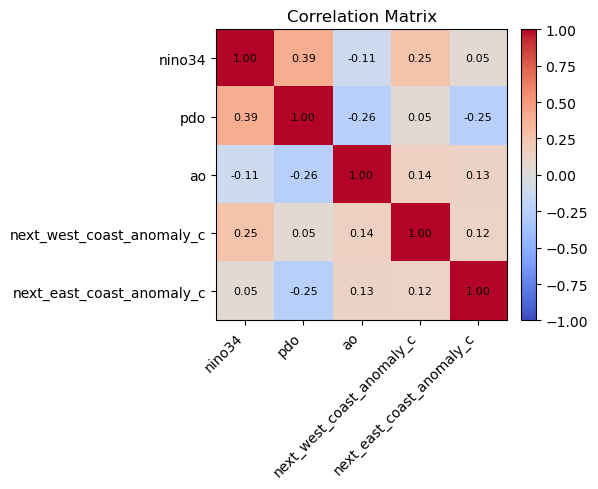

In [11]:
correlation_columns = [
    "nino34",
    "pdo",
    "ao",
    "next_west_coast_anomaly_c",
    "next_east_coast_anomaly_c",
]
correlation_matrix = modeling_data[correlation_columns].corr()

print(correlation_matrix.round(2))

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_columns)

for row in range(len(correlation_columns)):
    for col in range(len(correlation_columns)):
        ax.text(col, row, f"{correlation_matrix.iloc[row, col]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation Matrix")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Multiple Regression and Time-Ordered Validation

We use a chronological split: the first 80% of seasons for training and the last 20% for testing. This is more realistic than a random split because we are predicting future seasons from past seasons.

We compare four models for each coast:

- Baseline: predicts the training-set mean anomaly.
- Niño-only regression.
- Niño + PDO regression.
- Full multiple regression with Niño 3.4, PDO, and AO.

In [12]:
def evaluate_region_models(data, target_column, region_name):
    model_specs = {
        "Baseline mean": [],
        "Niño only": ["nino34"],
        "Niño + PDO": ["nino34", "pdo"],
        "Full model": ["nino34", "pdo", "ao"],
    }

    split_index = int(len(data) * 0.80)
    train_data = data.iloc[:split_index].copy()
    test_data = data.iloc[split_index:].copy()

    y_train = train_data[target_column].values
    y_test = test_data[target_column].values

    results = []
    full_model_test = None

    for model_name, predictor_columns in model_specs.items():
        if model_name == "Baseline mean":
            predictions = np.repeat(y_train.mean(), len(test_data))
            coefficient_text = "none"
        else:
            model = LinearRegression()
            model.fit(train_data[predictor_columns], y_train)
            predictions = model.predict(test_data[predictor_columns])
            coefficient_text = ", ".join(
                f"{name}: {coef:.3f}" for name, coef in zip(predictor_columns, model.coef_)
            )

            if model_name == "Full model":
                full_model_test = test_data[[
                    "target_season_label",
                    "target_season",
                    target_column,
                ]].copy()
                full_model_test = full_model_test.rename(columns={target_column: "observed"})
                full_model_test["predicted"] = predictions
                full_model_test["residual"] = full_model_test["observed"] - full_model_test["predicted"]
                full_model_test["region"] = region_name

        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)

        if np.std(predictions) == 0 or np.std(y_test) == 0:
            test_correlation = np.nan
        else:
            test_correlation = np.corrcoef(y_test, predictions)[0, 1]

        results.append({
            "region": region_name,
            "model": model_name,
            "predictors": ", ".join(predictor_columns) if predictor_columns else "none",
            "train_n": len(train_data),
            "test_n": len(test_data),
            "rmse": rmse,
            "mae": mae,
            "test_correlation": test_correlation,
            "coefficients": coefficient_text,
        })

    return pd.DataFrame(results), full_model_test

west_results, west_full_test = evaluate_region_models(
    modeling_data,
    "next_west_coast_anomaly_c",
    "West Coast",
)

east_results, east_full_test = evaluate_region_models(
    modeling_data,
    "next_east_coast_anomaly_c",
    "East Coast",
)

model_results = pd.concat([west_results, east_results], ignore_index=True)
full_model_predictions = pd.concat([west_full_test, east_full_test], ignore_index=True)

print(model_results[[
    "region",
    "model",
    "predictors",
    "rmse",
    "mae",
    "test_correlation",
    "coefficients",
]].round(3))

       region          model       predictors   rmse    mae  test_correlation  \
0  West Coast  Baseline mean             none  1.174  1.025             0.000   
1  West Coast      Niño only           nino34  1.117  0.971             0.316   
2  West Coast     Niño + PDO      nino34, pdo  1.134  0.992             0.363   
3  West Coast     Full model  nino34, pdo, ao  1.115  0.962             0.363   
4  East Coast  Baseline mean             none  1.089  0.964            -0.000   
5  East Coast      Niño only           nino34  1.093  0.968            -0.077   
6  East Coast     Niño + PDO      nino34, pdo  1.028  0.902             0.253   
7  East Coast     Full model  nino34, pdo, ao  1.026  0.900             0.265   

                            coefficients  
0                                   none  
1                          nino34: 0.203  
2              nino34: 0.184, pdo: 0.037  
3   nino34: 0.188, pdo: 0.076, ao: 0.174  
4                                   none  
5           

## Seasonal Model Performance

We also summarize the full model by target season. This helps us see whether predictability is stronger in some seasons than others.

In [13]:
season_performance_rows = []

for (region_name, target_season), group in full_model_predictions.groupby(["region", "target_season"]):
    if len(group) >= 3:
        rmse = np.sqrt(mean_squared_error(group["observed"], group["predicted"]))
        mae = mean_absolute_error(group["observed"], group["predicted"])

        if np.std(group["predicted"]) == 0 or np.std(group["observed"]) == 0:
            test_correlation = np.nan
        else:
            test_correlation = np.corrcoef(group["observed"], group["predicted"])[0, 1]

        season_performance_rows.append({
            "region": region_name,
            "target_season": target_season,
            "test_n": len(group),
            "rmse": rmse,
            "mae": mae,
            "test_correlation": test_correlation,
        })

season_performance = pd.DataFrame(season_performance_rows)
season_performance["target_season"] = pd.Categorical(
    season_performance["target_season"],
    categories=SEASON_ORDER,
    ordered=True,
)
season_performance = season_performance.sort_values(["region", "target_season"])

print(season_performance.round(3))

       region target_season  test_n   rmse    mae  test_correlation
0  East Coast           DJF      13  1.457  1.328             0.409
2  East Coast           MAM      13  0.922  0.834             0.477
1  East Coast           JJA      13  0.739  0.697             0.244
3  East Coast           SON      14  0.849  0.753            -0.099
4  West Coast           DJF      13  1.168  0.921             0.446
6  West Coast           MAM      13  1.034  0.897             0.562
5  West Coast           JJA      13  1.259  1.162             0.052
7  West Coast           SON      14  0.988  0.874             0.090


## Residual Checks

Residual checks help us see whether the full model has large errors or clear patterns in the test period. We keep this check compact: summary statistics plus one observed-vs-predicted plot.

Residual summary for the full model:
            count   mean    std    min    25%    50%    75%    max
region                                                            
East Coast   53.0  0.884  0.527 -0.319  0.538  0.879  1.144  2.178
West Coast   53.0  0.912  0.647 -0.534  0.568  0.885  1.407  2.832


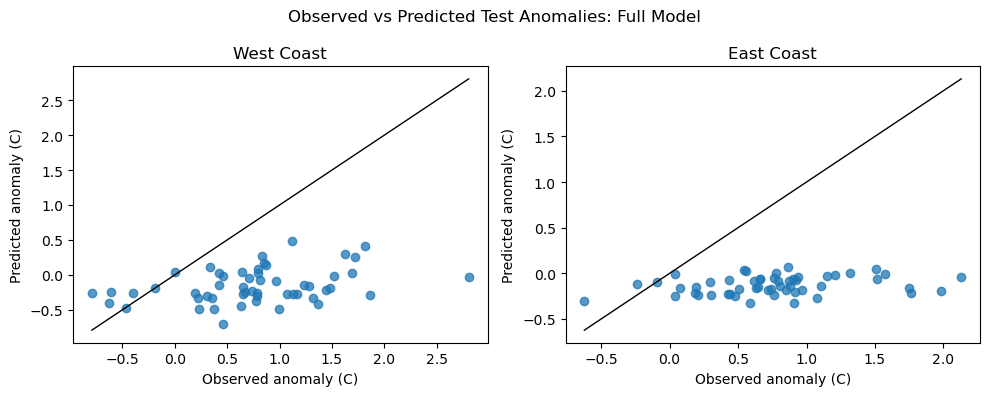

In [14]:
print("Residual summary for the full model:")
print(full_model_predictions.groupby("region")["residual"].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=False, sharey=False)

for ax, region_name in zip(axes, ["West Coast", "East Coast"]):
    region_predictions = full_model_predictions[full_model_predictions["region"] == region_name]
    ax.scatter(region_predictions["observed"], region_predictions["predicted"], alpha=0.75)

    axis_min = min(region_predictions["observed"].min(), region_predictions["predicted"].min())
    axis_max = max(region_predictions["observed"].max(), region_predictions["predicted"].max())
    ax.plot([axis_min, axis_max], [axis_min, axis_max], color="black", linewidth=1)

    ax.set_title(region_name)
    ax.set_xlabel("Observed anomaly (C)")
    ax.set_ylabel("Predicted anomaly (C)")

plt.suptitle("Observed vs Predicted Test Anomalies: Full Model")
plt.tight_layout()
plt.show()

## Interpretation

This notebook gives us a structured way to compare predictability across two coastal regions.

Key points to interpret from the outputs:

- If the full model beats the baseline, the climate indices add useful one-season-ahead signal.
- If the West Coast and East Coast have different test errors, the climate indices may be more useful for one coast than the other.
- If seasonal performance differs, the climate signal may be season-dependent.
- If adding PDO and AO does not improve test performance, the simpler Niño-only model may be easier to explain.

A more complex model should come after the linear baseline is clear and well validated.